## AI Recruitment Screening Assistant (Prototype)

### 1. PROJECT INTRODUCTION

Recruitment screening is the initial phase of the hiring process where job applications, primarily resumes, are reviewed to identify candidates who meet the basic qualifications for a role. Traditionally, this process is highly manual, labor-intensive, and prone to human biases, leading to inefficiencies and potentially overlooking qualified candidates.

The problems with manual resume screening are multifaceted:

*   **Time-Consuming**: Recruiters spend a significant amount of time sifting through hundreds or thousands of resumes for a single position.
*   **Inconsistency**: Screening criteria can vary between recruiters or even for the same recruiter over time, leading to inconsistent evaluations.
*   **Human Bias**: Unconscious biases related to gender, age, ethnicity, or other non-job-related factors can inadvertently influence screening decisions.
*   **High Volume**: For popular positions, the sheer volume of applications can overwhelm human capacity, leading to hurried reviews and potential errors.
*   **Subjectivity**: Manual review often involves subjective interpretation of skills and experience, which can be inconsistent.

Natural Language Processing (NLP) offers a powerful solution to augment this process. By leveraging NLP techniques, we can automate the extraction of key information from resumes and job descriptions, objectively match candidate profiles to job requirements, and significantly reduce the time and effort involved in initial screening. This allows human recruiters to focus on more strategic tasks, such as in-depth interviews and relationship building.

This prototype aims to build an AI Recruitment Screening Assistant that:

*   Scores synthetic resumes against a sample job description based on skill relevance.
*   Ranks candidates based on their compatibility scores.
*   Provides clear, explainable reasons for the assigned scores.
*   Identifies and flags potential bias risks inherent in automated screening systems.

**What this system does NOT do:**

It is crucial to understand that this prototype is a decision-support tool. It does **NOT** make autonomous hiring decisions, nor does it possess true understanding or judgment. It relies on predefined rules, skill dictionaries, and NLP models to provide quantitative insights. It is explicitly designed *without* deep learning or advanced LLM APIs to demonstrate a strong understanding of traditional NLP and machine learning concepts.

**Why human review is still required:**

Despite the advancements in AI, human oversight remains indispensable in the recruitment process. Humans bring empathy, nuanced understanding, cultural context, and the ability to detect and mitigate biases that automated systems might miss. Final hiring decisions require human judgment to assess soft skills, cultural fit, and personal potential, ensuring fairness, legal compliance, and ethical considerations. This tool is intended to assist, not replace, the critical role of human recruiters.

### 2. PROJECT OBJECTIVES

The primary objectives of this AI Recruitment Screening Assistant prototype are to:

*   **Extract Relevant Skills from Job Descriptions**: Automatically identify and categorize required and preferred skills specified in a job description.
*   **Extract Relevant Skills from Resumes**: Accurately detect and normalize skills present in candidate resumes.
*   **Calculate Candidate-Job Compatibility**: Develop a scoring mechanism that quantifies how well a candidate's skills align with a given job description.
*   **Rank Candidates**: Order candidates based on their compatibility scores, from highest to lowest.
*   **Explain Candidate Scores**: Provide clear, interpretable explanations for why a candidate received a particular score, highlighting strengths and missing skills.
*   **Identify Missing Skills**: Pinpoint specific required or preferred skills that a candidate lacks.
*   **Reduce Irrelevant Screening Factors**: Design the system to focus solely on job-relevant skills and experience, explicitly ignoring protected attributes.
*   **Analyze Potential Bias**: Evaluate and document potential sources of bias within the automated screening process and verify that the system does not score based on irrelevant demographic information.
*   **Demonstrate an Interpretable NLP Pipeline**: Showcase a robust, transparent, and understandable NLP and machine learning workflow suitable for an AI/ML internship.

### 3. CREATE A REALISTIC JOB DESCRIPTION

Here is a synthetic job description for an 'AI/ML Intern' role. This description includes the job title, responsibilities, clearly separated required and preferred skills, education, experience, and projects/technical requirements, incorporating a variety of relevant AI/ML skills.

In [ ]:
job_description = """
Job Title: AI/ML Intern

Responsibilities:
- Assist in the development, testing, and deployment of machine learning models.
- Participate in data collection, preprocessing, and feature engineering.
- Conduct exploratory data analysis to identify patterns and insights.
- Research and evaluate new AI/ML techniques and tools.
- Collaborate with team members on various AI/ML projects.
- Document code, models, and experimental results.

REQUIRED SKILLS:
- Programming: Python (advanced), SQL
- Libraries: NumPy, Pandas, Scikit-learn, TensorFlow or PyTorch
- Concepts: Machine Learning (Supervised, Unsupervised), Statistics, Data Structures
- Tools: Git (version control)

PREFERRED SKILLS:
- Programming: R, Java
- Libraries: Keras, Matplotlib, Seaborn, spaCy, NLTK
- Concepts: Deep Learning, Natural Language Processing (NLP), Computer Vision
- Tools: Docker, AWS/GCP/Azure (basic familiarity)
- Experience: Building and deploying ML models, data visualization

Education:
- Currently pursuing a Bachelor's or Master's degree in Computer Science, Data Science, Artificial Intelligence, or a related technical field.

Experience:
- Prior internship or project experience in AI/ML, data analysis, or software development.

Projects/Technical Requirements:
- Demonstrated experience with at least one significant AI/ML project (academic or personal).
- Strong problem-solving abilities and analytical thinking.
- Ability to work independently and in a team environment.
"""

print("Job Description created successfully!")


Job Description created successfully!


### Project Architecture Outline

The project will be structured into the following logical components, aligning with the proposed pipeline:

1.  **Data Ingestion & Preparation**: Handling the job description and synthetic resumes.
2.  **Preprocessing Module**: A reusable function for cleaning text data.
3.  **Skill Ontology/Dictionary**: A central mapping for skills and their synonyms.
4.  **Skill Extraction Module**: A function to identify and normalize skills from text.
5.  **Scoring Module**:
    *   **Keyword Matching**: Baseline skill-based scoring.
    *   **Weighted Skill Scoring**: Enhanced skill-based scoring with importance weights.
    *   **TF-IDF + Cosine Similarity**: Semantic similarity scoring.
    *   **Combined Scoring**: A weighted combination of skill-based and semantic scores.
6.  **Analysis & Explanation Module**: Generating explanations, missing skill analysis, and category analysis.
7.  **Bias & Fairness Module**: Tools for testing and analyzing potential biases.
8.  **Validation Module**: For manual validation and simple metrics.
9.  **Visualization Module**: For generating insightful plots.
10. **Reporting Module**: For generating the final report.

### Dataset Design for Synthetic Resumes

We will create a Pandas DataFrame where each row represents a candidate's resume. The DataFrame will have the following columns:

*   **Candidate ID**: Unique identifier (e.g., `Candidate_01`).
*   **Education**: Textual description of educational background.
*   **Experience**: Textual description of work experience.
*   **Skills**: Textual description of technical and soft skills.
*   **Projects**: Textual description of relevant projects.
*   **Certifications**: Textual description of any certifications.
*   **Resume Text**: A concatenated string of all relevant sections (Education, Experience, Skills, Projects, Certifications) to be used for NLP tasks. This column will be generated from the other columns for convenience.

The content of these columns will be intentionally varied to create diverse candidate profiles, ranging from strong matches to weak or irrelevant matches for the 'AI/ML Intern' role.

### 4. CREATE 10 SYNTHETIC RESUMES

Below are the detailed contents for 10 synthetic resumes. These resumes are designed to be intentionally diverse, covering various levels of relevance to the 'AI/ML Intern' job description, and explicitly avoid any real personal data. Each resume follows the specified structure:

1.  **Candidate_01 (Strong ML Candidate)**: Excellent match with strong ML, Python, and relevant tools.
2.  **Candidate_02 (Strong Python/Data Science Candidate)**: Good foundational skills in Python, data science, and some ML, but perhaps less deep learning experience.
3.  **Candidate_03 (Strong Web-Development Candidate with Limited ML)**: Strong programming skills (e.g., JavaScript, React) but limited AI/ML exposure, potentially a partial match if transferable skills are recognized.
4.  **Candidate_04 (Strong NLP Candidate)**: Specialized in NLP with relevant libraries, strong Python, but maybe less general ML/Deep Learning.
5.  **Candidate_05 (Strong Deep Learning Candidate)**: Focus on deep learning frameworks (TensorFlow, PyTorch), strong research background.
6.  **Candidate_06 (Strong Academic Background but Fewer Projects)**: High academic achievements, theoretical understanding, but fewer practical projects listed.
7.  **Candidate_07 (Many Preferred Skills but Missing Important Required Skills)**: Has many preferred skills (e.g., Docker, AWS) but lacks some core required ML/Python skills.
8.  **Candidate_08 (Partial Skill Overlap)**: Moderate overlap, some required skills, some preferred, but not excelling in any specific area.
9.  **Candidate_09 (Unrelated Technical Skills)**: Strong technical skills, but in a different domain (e.g., cybersecurity, embedded systems), a weak match for AI/ML.
10. **Candidate_10 (Moderate Overall Match)**: A balanced candidate with decent exposure to most required skills and some preferred, a good all-rounder.

In [ ]:
synthetic_resumes_data = [
    {
        "Candidate ID": "Candidate_01",
        "Education": "M.S. in Artificial Intelligence, University of Tech (2023). B.S. in Computer Science, State University (2021).",
        "Experience": "ML Intern at InnovateTech (2022-2023): Developed predictive models using Scikit-learn and TensorFlow. Implemented data pipelines with Pandas. Research Assistant at University Lab (2021): Worked on NLP projects using PyTorch.",
        "Skills": "Python, Machine Learning, Deep Learning, NumPy, Pandas, Scikit-learn, TensorFlow, PyTorch, SQL, Git, NLP, Data Structures, Statistics, Matplotlib, Seaborn, Data Visualization.",
        "Projects": "Personal Project: Sentiment Analysis with BERT (PyTorch). Academic Project: Image Classification using CNNs (TensorFlow).",
        "Certifications": "Deep Learning Specialization (Coursera).",
        "Resume Text": ""
    },
    {
        "Candidate ID": "Candidate_02",
        "Education": "B.S. in Data Science, Central University (2022).",
        "Experience": "Data Analyst Intern at DataInsights Co. (2021-2022): Performed data cleaning and analysis using Pandas and NumPy. Created dashboards with Tableau. Software Developer Intern at WebSolutions (2020): Developed Python scripts for backend tasks.",
        "Skills": "Python, Pandas, NumPy, SQL, Excel, Data Analysis, Statistics, Data Visualization, Matplotlib, Seaborn, Basic Machine Learning (Scikit-learn), Git, Web Development (Flask).",
        "Projects": "Academic Project: Customer Churn Prediction (Scikit-learn). Personal Project: Exploratory Data Analysis of E-commerce sales.",
        "Certifications": "Data Science Professional Certificate (IBM).",
        "Resume Text": ""
    },
    {
        "Candidate ID": "Candidate_03",
        "Education": "B.S. in Software Engineering, Tech Institute (2023).",
        "Experience": "Frontend Developer Intern at UI/UX Corp (2022-2023): Developed user interfaces using React and JavaScript. Backend Developer Intern at API Builders (2021): Built REST APIs with Node.js and Express.",
        "Skills": "JavaScript, React, Node.js, HTML, CSS, SQL, Git, AWS (basic), Docker (basic), Agile Methodologies, Problem Solving, Communication, Python (intermediate).",
        "Projects": "Personal Project: E-commerce Website (React, Node.js). Academic Project: Collaborative Task Management App.",
        "Certifications": "Full-Stack Web Development Bootcamp.",
        "Resume Text": ""
    },
    {
        "Candidate ID": "Candidate_04",
        "Education": "M.S. in Computational Linguistics, Language University (2024 - expected). B.A. in Linguistics with Computer Science Minor (2022).",
        "Experience": "NLP Research Assistant at TextMining Lab (2022-2023): Worked on text classification and sentiment analysis using spaCy and NLTK. Developed custom NLP pipelines. Teaching Assistant for 'Introduction to Python' (2021-2022).",
        "Skills": "Python, NLP, spaCy, NLTK, Machine Learning (Scikit-learn), Pandas, NumPy, Statistics, Linguistics, Text Preprocessing, Git, PyTorch (basic), Data Structures.",
        "Projects": "Academic Project: Named Entity Recognition for historical texts. Personal Project: Chatbot development using rule-based and ML approaches.",
        "Certifications": "NLP Specialization (DeepLearning.AI).",
        "Resume Text": ""
    },
    {
        "Candidate ID": "Candidate_05",
        "Education": "Ph.D. Candidate in Deep Learning, Advanced Research Institute (2025 - expected). M.S. in Computer Vision, Vision University (2022).",
        "Experience": "Deep Learning Researcher at AI Labs (2022-2023): Designed and trained CNNs for medical image analysis using TensorFlow and Keras. Published 2 conference papers. Graduate Teaching Assistant for 'Deep Learning Fundamentals' (2021-2022).",
        "Skills": "Deep Learning, TensorFlow, Keras, PyTorch, Computer Vision, CNNs, RNNs, Machine Learning, Python (advanced), NumPy, Pandas, Git, LaTeX, Scientific Writing, Experiment Design.",
        "Projects": "Dissertation: Novel Architectures for Few-Shot Learning. Academic Project: Object Detection using YOLOv3 (PyTorch).",
        "Certifications": "Google TensorFlow Developer Certificate.",
        "Resume Text": ""
    },
    {
        "Candidate ID": "Candidate_06",
        "Education": "B.S. in Theoretical Computer Science, Prestigious College (2023). GPA: 3.9/4.0.",
        "Experience": "Academic Tutor for Algorithms and Data Structures (2021-2023). Research Assistant for formal methods in AI (2022): Focused on theoretical aspects of AI.",
        "Skills": "Python, Java, C++, Data Structures, Algorithms, Discrete Mathematics, Logic, Theoretical Computer Science, Machine Learning (conceptual understanding), Statistics, Git (basic).",
        "Projects": "Academic Project: Implementation of various sorting algorithms. Academic Project: Proof-of-concept for a new cryptographic protocol.",
        "Certifications": "None listed.",
        "Resume Text": ""
    },
    {
        "Candidate ID": "Candidate_07",
        "Education": "B.S. in Computer Engineering, Global University (2023).",
        "Experience": "DevOps Intern at CloudHost (2022-2023): Managed CI/CD pipelines using Docker and Kubernetes. Deployed applications on AWS. IT Support Specialist (2021): Resolved technical issues.",
        "Skills": "Docker, Kubernetes, AWS, Linux, Shell Scripting, Git, CI/CD, Networking, Cloud Computing, Problem Solving, Communication, Python (basic), SQL (basic).",
        "Projects": "Personal Project: Automated Server Provisioning with Ansible. Academic Project: Building a scalable web service using microservices architecture.",
        "Certifications": "AWS Certified Cloud Practitioner.",
        "Resume Text": ""
    },
    {
        "Candidate ID": "Candidate_08",
        "Education": "B.S. in Applied Mathematics, Metropolitan University (2023).",
        "Experience": "Junior Analyst at QuantFirm (2022-2023): Assisted in quantitative research using MATLAB and some Python scripting. Intern at Fintech Solutions (2021): Data entry and basic reporting.",
        "Skills": "Mathematics, Statistics, Probability, MATLAB, Python, Excel, Data Analysis, Report Writing, Communication, NumPy (basic), Pandas (basic), SQL (basic), Git (basic).",
        "Projects": "Academic Project: Financial Market Prediction using time series analysis. Personal Project: Simple linear regression model in Python.",
        "Certifications": "Financial Modeling & Valuation Analyst (FMVA).",
        "Resume Text": ""
    },
    {
        "Candidate ID": "Candidate_09",
        "Education": "B.S. in Electrical Engineering, Technical College (2023).",
        "Experience": "Embedded Systems Intern at DeviceCo (2022-2023): Programmed microcontrollers in C/C++. Designed circuit boards. Quality Assurance Tester (2021): Performed manual and automated testing.",
        "Skills": "C/C++, Embedded Systems, Microcontrollers, Circuit Design, Linux, Troubleshooting, Testing, Hardware, Python (basic scripting), Git (basic).",
        "Projects": "Academic Project: Smart Home Automation System. Personal Project: Robotic Arm Control System.",
        "Certifications": "Certified Embedded Systems Engineer.",
        "Resume Text": ""
    },
    {
        "Candidate ID": "Candidate_10",
        "Education": "B.S. in Computer Science, City University (2023).",
        "Experience": "Software Development Intern at StartupX (2022-2023): Contributed to a Python-based web application. Data Entry Specialist (2021).",
        "Skills": "Python, Java, Data Structures, Algorithms, SQL, Git, Problem Solving, Communication, Linux (basic), Machine Learning (introductory concepts), Scikit-learn (basic), Pandas (basic), NumPy (basic).",
        "Projects": "Academic Project: Simple recommendation system. Personal Project: Basic inventory management system.",
        "Certifications": "None listed.",
        "Resume Text": ""
    }
]

print("Synthetic resumes data created successfully!")

Synthetic resumes data created successfully!


### Scoring Methodology

The scoring will combine two main approaches to provide a comprehensive candidate evaluation:

1.  **Weighted Skill Scoring (70% weight)**:
    *   **Skill Extraction**: Identify all skills from the job description and each resume using a predefined skill dictionary that handles synonyms and abbreviations.
    *   **Required vs. Preferred**: Categorize skills from the job description into 'Required' and 'Preferred'.
    *   **Skill Weights**: Assign numerical weights to individual skills based on their importance (e.g., Python, Machine Learning might have higher weights).
    *   **Candidate Skill Match**: Calculate a score based on the sum of weights of matched required and preferred skills. Penalize missing required skills more heavily.
    *   **Normalization**: Normalize the final skill score to a 0-100 scale.

2.  **TF-IDF + Cosine Similarity (30% weight)**:
    *   **Text Representation**: Use `TfidfVectorizer` to convert the preprocessed job description and each preprocessed resume into numerical TF-IDF vectors.
    *   **Semantic Similarity**: Calculate the cosine similarity between the TF-IDF vector of the job description and each resume's TF-IDF vector.
    *   **Normalization**: Normalize this similarity score to a 0-100 scale.

**Combined Final Score**:

The two scores will be combined using a weighted average:

`Final Score = (0.70 * Weighted Skill Score) + (0.30 * TF-IDF Similarity Score)`

The higher weight for the Weighted Skill Score emphasizes the importance of specific skill matching, which is often crucial in technical roles, while the TF-IDF score provides a general semantic alignment.

### 5. DATASET CREATION

We will now convert the list of synthetic resume dictionaries into a Pandas DataFrame. This DataFrame will serve as our primary dataset for the recruitment screening process. After creating the DataFrame, we will inspect its basic properties, including its shape, column names, a sample of records, and check for any missing values. Finally, the dataset will be saved as a CSV file for future use.

In [ ]:
import pandas as pd

# Create a DataFrame from the synthetic resumes data
df_resumes = pd.DataFrame(synthetic_resumes_data)

# Concatenate all relevant text fields into a single 'Resume Text' column
def combine_resume_text(row):
    return f"{row['Education']} {row['Experience']} {row['Skills']} {row['Projects']} {row['Certifications']}"

df_resumes['Resume Text'] = df_resumes.apply(combine_resume_text, axis=1)

print("### Dataset Information:")
print(f"Shape of the DataFrame: {df_resumes.shape}")
print("\nColumns in the DataFrame:")
print(df_resumes.columns.tolist())

print("\n### Sample Records (first 3 rows):")
display(df_resumes.head(3))

print("\n### Missing Values:")
print(df_resumes.isnull().sum())

# Save the dataset to a CSV file
df_resumes.to_csv('synthetic_resumes.csv', index=False)
print("\nDataset saved as 'synthetic_resumes.csv'")

# Display basic statistics for numerical columns if any (not applicable for this text-heavy dataset, but good practice)
# print("\n### Basic Statistics:")
# display(df_resumes.describe(include='all'))

### Dataset Information:
Shape of the DataFrame: (10, 7)

Columns in the DataFrame:
['Candidate ID', 'Education', 'Experience', 'Skills', 'Projects', 'Certifications', 'Resume Text']

### Sample Records (first 3 rows):


,Candidate ID,Education,Experience,Skills,Projects,Certifications,Resume Text
0,Candidate_01,"M.S. in Artificial Intelligence, University of...",ML Intern at InnovateTech (2022-2023): Develop...,"Python, Machine Learning, Deep Learning, NumPy...",Personal Project: Sentiment Analysis with BERT...,Deep Learning Specialization (Coursera).,"M.S. in Artificial Intelligence, University of..."
1,Candidate_02,"B.S. in Data Science, Central University (2022).",Data Analyst Intern at DataInsights Co. (2021-...,"Python, Pandas, NumPy, SQL, Excel, Data Analys...",Academic Project: Customer Churn Prediction (S...,Data Science Professional Certificate (IBM).,"B.S. in Data Science, Central University (2022..."
2,Candidate_03,"B.S. in Software Engineering, Tech Institute (...",Frontend Developer Intern at UI/UX Corp (2022-...,"JavaScript, React, Node.js, HTML, CSS, SQL, Gi...","Personal Project: E-commerce Website (React, N...",Full-Stack Web Development Bootcamp.,"B.S. in Software Engineering, Tech Institute (..."



### Missing Values:
Candidate ID      0
Education         0
Experience        0
Skills            0
Projects          0
Certifications    0
Resume Text       0
dtype: int64

Dataset saved as 'synthetic_resumes.csv'


### 6. TEXT PREPROCESSING

Text preprocessing is a crucial step in any NLP pipeline to clean and normalize text data, making it suitable for analysis and model training. The goal is to reduce noise and enhance the consistency of the text without losing valuable information, especially for skill matching. We will create a reusable function for this purpose.

Here are the preprocessing steps we will implement:

1.  **Lowercase Conversion**: Convert all text to lowercase to ensure consistency and treat words like 'Python' and 'python' as the same. This is essential for effective keyword and skill matching.
2.  **Punctuation Removal**: Remove common punctuation marks. While some punctuation can be contextually important, for skill extraction and TF-IDF, it often acts as noise and can interfere with matching (e.g., 'Python,' vs 'Python').
3.  **Whitespace Normalization**: Replace multiple spaces, tabs, and newlines with a single space. This helps in standardizing the text format.
4.  **Optional Stopword Removal**: We will initially *avoid* general stopword removal at this stage because some stopwords (e.g., 'R' as a programming language, 'A/B testing' where 'A/B' could be affected by stopword lists) might be relevant for skill identification. If necessary, a more targeted stopword removal can be considered later, or it can be a configurable option. For now, we prioritize retaining information.
5.  **Tokenization (Implicit in TF-IDF)**: While not explicitly a step in this general function, downstream processes like TF-IDF will handle tokenization. The current function focuses on cleaning the raw text string.

In [ ]:
import re
import nltk
# Optional: Download stopwords if using them later
# nltk.download('stopwords')
# from nltk.corpus import stopwords

def preprocess_text(text):
    """
    Performs basic text preprocessing steps:
    - Lowercase conversion
    - Punctuation removal
    - Whitespace normalization
    - **UPDATE**: Also removes numbers to mitigate age-related bias from years.
    """
    if not isinstance(text, str):
        return ""

    # 1. Lowercase conversion
    text = text.lower()

    # 2. Punctuation and Number removal
    # Modified regex to keep only alphabetic characters and spaces (removes numbers and most punctuation)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 3. Whitespace normalization (replace multiple spaces with a single space)
    text = re.sub(r'\s+', ' ', text).strip()

    # Optional: Stopword removal (commented out as per instructions to avoid losing info)
    # stop_words = set(stopwords.words('english'))
    # words = text.split()
    # filtered_words = [word for word in words if word not in stop_words]
    # text = ' '.join(filtered_words)

    return text

# Demonstrate the function on the job description
print("### Preprocessing Demonstration on Job Description")
print("Original Job Description (excerpt):\n", job_description[:300], "...")
preprocessed_jd = preprocess_text(job_description)
print("\nPreprocessed Job Description (excerpt):\n", preprocessed_jd[:300], "...")

# Demonstrate on a sample resume
print("\n### Preprocessing Demonstration on a Sample Resume (Candidate_01)")
sample_resume_text = df_resumes.loc[df_resumes['Candidate ID'] == 'Candidate_01', 'Resume Text'].iloc[0]
print("Original Resume Text (excerpt):\n", sample_resume_text[:300], "...")
preprocessed_sample_resume = preprocess_text(sample_resume_text)
print("\nPreprocessed Resume Text (excerpt):\n", preprocessed_sample_resume[:300], "...")

### Preprocessing Demonstration on Job Description
Original Job Description (excerpt):
 
Job Title: AI/ML Intern

Responsibilities:
- Assist in the development, testing, and deployment of machine learning models.
- Participate in data collection, preprocessing, and feature engineering.
- Conduct exploratory data analysis to identify patterns and insights.
- Research and evaluate new AI ...

Preprocessed Job Description (excerpt):
 job title aiml intern responsibilities assist in the development testing and deployment of machine learning models participate in data collection preprocessing and feature engineering conduct exploratory data analysis to identify patterns and insights research and evaluate new aiml techniques and to ...

### Preprocessing Demonstration on a Sample Resume (Candidate_01)
Original Resume Text (excerpt):
 M.S. in Artificial Intelligence, University of Tech (2023). B.S. in Computer Science, State University (2021). ML Intern at InnovateTech (2022-2023): Developed 

### 7. SKILL DICTIONARY / SKILL ONTOLOGY

To accurately identify skills from unstructured text (job descriptions and resumes) and handle variations in how they are expressed (e.g., 'machine learning' vs. 'ML', 'scikit-learn' vs. 'sklearn'), a comprehensive skill dictionary or ontology is essential. This dictionary will map various phrases and abbreviations to standardized skill names and categorize them for better analysis.

**Structure of the Skill Dictionary:**

The dictionary will be a Python dictionary where:

*   **Keys** are standardized skill names (e.g., 'machine learning', 'python').
*   **Values** are lists of synonyms, abbreviations, and common alternative spellings associated with that standardized skill. The standardized skill name itself should also be included in its list of synonyms.

**Categories:**

We will categorize skills to provide a structured view and enable analysis based on skill types. The categories will include:

*   `Programming`
*   `Data Science`
*   `Machine Learning`
*   `Deep Learning`
*   `Natural Language Processing`
*   `Databases`
*   `Visualization`
*   `Cloud`
*   `Tools`
*   `Other` (for general concepts or soft skills that are still technical/relevant)

This structured approach ensures that our skill extraction is robust and consistent, laying the groundwork for accurate scoring and analysis.

In [ ]:
# Define the skill ontology/dictionary with standardized names and their synonyms
skill_ontology = {
    "Programming": {
        "python": ["python", "py", "python programming"],
        "r": ["r", "rstudio", "r programming"],
        "java": ["java", "java programming"],
        "c++": ["c++", "cpp", "cplusplus"],
        "sql": ["sql", "postgresql", "mysql", "sqlite", "database query", "sql server", "oracle sql"],
        "javascript": ["javascript", "js", "node.js", "react", "angular", "vuejs"],
        "scala": ["scala"],
        "bash": ["bash", "shell scripting", "linux scripting"]
    },
    "Data Science": {
        "pandas": ["pandas", "pd"],
        "numpy": ["numpy", "np"],
        "scipy": ["scipy"],
        "data analysis": ["data analysis", "data analytics", "eda", "exploratory data analysis"],
        "statistics": ["statistics", "statistical analysis", "hypothesis testing"],
        "excel": ["excel", "microsoft excel", "advanced excel"],
        "tableau": ["tableau"],
        "power bi": ["power bi"],
        "data visualization": ["data visualization", "dataviz"]
    },
    "Machine Learning": {
        "machine learning": ["machine learning", "ml", "supervised learning", "unsupervised learning", "reinforcement learning"],
        "scikit-learn": ["scikit-learn", "sklearn"],
        "xgboost": ["xgboost", "xgb"],
        "lightgbm": ["lightgbm", "lgbm"],
        "model deployment": ["model deployment", "mlops"],
        "feature engineering": ["feature engineering"],
        "model evaluation": ["model evaluation", "metrics", "cross-validation"]
    },
    "Deep Learning": {
        "deep learning": ["deep learning", "dl"],
        "tensorflow": ["tensorflow", "tf"],
        "pytorch": ["pytorch", "torch"],
        "keras": ["keras"],
        "cnns": ["cnns", "convolutional neural networks", "computer vision"],
        "rnns": ["rnns", "recurrent neural networks"],
        "transformers": ["transformers", "bert", "gpt", "encoder decoder models"]
    },
    "Natural Language Processing": {
        "natural language processing": ["natural language processing", "nlp"],
        "spacy": ["spacy"],
        "nltk": ["nltk"],
        "text classification": ["text classification"],
        "sentiment analysis": ["sentiment analysis"],
        "ner": ["ner", "named entity recognition"]
    },
    "Databases": {
        "mongodb": ["mongodb", "nosql"],
        "cassandra": ["cassandra"],
        "data warehousing": ["data warehousing", "data lake"],
        "etl": ["etl", "extract transform load"]
    },
    "Visualization": {
        "matplotlib": ["matplotlib", "plt"],
        "seaborn": ["seaborn", "sns"],
        "plotly": ["plotly"],
        "bokeh": ["bokeh"]
    },
    "Cloud": {
        "aws": ["aws", "amazon web services"],
        "azure": ["azure", "microsoft azure"],
        "gcp": ["gcp", "google cloud platform"],
        "docker": ["docker"],
        "kubernetes": ["kubernetes", "k8s"]
    },
    "Tools": {
        "git": ["git", "github", "gitlab", "bitbucket", "version control"],
        "jira": ["jira"],
        "confluence": ["confluence"],
        "airflow": ["airflow"]
    },
    "Other": {
        "agile": ["agile", "scrum"],
        "problem solving": ["problem solving", "analytical thinking"],
        "communication": ["communication", "teamwork"],
        "data structures": ["data structures", "algorithms"],
        "api": ["api", "rest api"],
        "linux": ["linux", "unix"]
    }
}

print("Skill Ontology created successfully with categories.")

# Flatten the skill ontology for easier lookup during extraction
# This creates a reverse map from preprocessed synonym -> standardized skill name
flattened_skill_map = {}
# Ensure preprocess_text is available, or define a local one if this cell runs independently
if 'preprocess_text' not in globals():
    import re
    def preprocess_text(text):
        if not isinstance(text, str):
            return ""
        text = text.lower()
        text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

for category, skills_map in skill_ontology.items():
    for standardized_skill_name, synonyms_list in skills_map.items():
        for syn in synonyms_list:
            preprocessed_syn = preprocess_text(syn)
            flattened_skill_map[preprocessed_syn] = standardized_skill_name

print("Flattened skill map created for efficient lookup with preprocessed synonyms.")


Skill Ontology created successfully with categories.
Flattened skill map created for efficient lookup with preprocessed synonyms.


### 8. SKILL EXTRACTION

This section implements the core logic for identifying skills within text. We will create a function `extract_skills(text)` that takes preprocessed text (either from a job description or a resume) and returns a list of standardized, unique skills found in that text. This function will utilize the `flattened_skill_map` created in the previous step.

**Function Logic:**

1.  **Preprocessing**: The input text will first be processed using our `preprocess_text` function to ensure consistency.
2.  **Iterate through Synonyms**: The function will iterate through all the `synonyms` (keys) in our `flattened_skill_map`.
3.  **Keyword Matching**: For each synonym, it will check if the synonym (as a whole word or phrase) is present in the preprocessed text.
4.  **Standardization**: If a synonym is found, its corresponding `standardized skill name` (value from `flattened_skill_map`) will be added to a set.
5.  **Uniqueness**: Using a set ensures that each standardized skill is only listed once, even if multiple synonyms for the same skill are found in the text.
6.  **Return**: The function will return a list of these unique, standardized skills.

This approach allows for robust skill detection that accounts for various ways skills might be mentioned.

In [ ]:
import re
import pandas as pd # Import pandas as df_resumes is used from it

# --- Re-including necessary definitions for self-contained demonstration ---
# In a typical notebook flow, these would be executed in their respective cells.

# Definition of preprocess_text (from Section 6)
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Definition of skill_ontology and flattened_skill_map (from Section 7)
# This is a fallback in case the original cells were not run.
if 'skill_ontology' not in globals():
    skill_ontology = {
        "Programming": {
            "python": ["python", "py", "python programming"],
            "r": ["r", "rstudio", "r programming"],
            "java": ["java", "java programming"],
            "c++": ["c++", "cpp", "cplusplus"],
            "sql": ["sql", "postgresql", "mysql", "sqlite", "database query", "sql server", "oracle sql"],
            "javascript": ["javascript", "js", "node.js", "react", "angular", "vuejs"],
            "scala": ["scala"],
            "bash": ["bash", "shell scripting", "linux scripting"]
        },
        "Data Science": {
            "pandas": ["pandas", "pd"],
            "numpy": ["numpy", "np"],
            "scipy": ["scipy"],
            "data analysis": ["data analysis", "data analytics", "eda", "exploratory data analysis"],
            "statistics": ["statistics", "statistical analysis", "hypothesis testing"],
            "excel": ["excel", "microsoft excel", "advanced excel"],
            "tableau": ["tableau"],
            "power bi": ["power bi"],
            "data visualization": ["data visualization", "dataviz"]
        },
        "Machine Learning": {
            "machine learning": ["machine learning", "ml", "supervised learning", "unsupervised learning", "reinforcement learning"],
            "scikit-learn": ["scikit-learn", "sklearn"],
            "xgboost": ["xgboost", "xgb"],
            "lightgbm": ["lightgbm", "lgbm"],
            "model deployment": ["model deployment", "mlops"],
            "feature engineering": ["feature engineering"],
            "model evaluation": ["model evaluation", "metrics", "cross-validation"]
        },
        "Deep Learning": {
            "deep learning": ["deep learning", "dl"],
            "tensorflow": ["tensorflow", "tf"],
            "pytorch": ["pytorch", "torch"],
            "keras": ["keras"],
            "cnns": ["cnns", "convolutional neural networks", "computer vision"],
            "rnns": ["rnns", "recurrent neural networks"],
            "transformers": ["transformers", "bert", "gpt", "encoder decoder models"]
        },
        "Natural Language Processing": {
            "natural language processing": ["natural language processing", "nlp"],
            "spacy": ["spacy"],
            "nltk": ["nltk"],
            "text classification": ["text classification"],
            "sentiment analysis": ["sentiment analysis"],
            "ner": ["ner", "named entity recognition"]
        },
        "Databases": {
            "mongodb": ["mongodb", "nosql"],
            "cassandra": ["cassandra"],
            "data warehousing": ["data warehousing", "data lake"],
            "etl": ["etl", "extract transform load"]
        },
        "Visualization": {
            "matplotlib": ["matplotlib", "plt"],
            "seaborn": ["seaborn", "sns"],
            "plotly": ["plotly"],
            "bokeh": ["bokeh"]
        },
        "Cloud": {
            "aws": ["aws", "amazon web services"],
            "azure": ["azure", "microsoft azure"],
            "gcp": ["gcp", "google cloud platform"],
            "docker": ["docker"],
            "kubernetes": ["kubernetes", "k8s"]
        },
        "Tools": {
            "git": ["git", "github", "gitlab", "bitbucket", "version control"],
            "jira": ["jira"],
            "confluence": ["confluence"],
            "airflow": ["airflow"]
        },
        "Other": {
            "agile": ["agile", "scrum"],
            "problem solving": ["problem solving", "analytical thinking"],
            "communication": ["communication", "teamwork"],
            "data structures": ["data structures", "algorithms"],
            "api": ["api", "rest api"],
            "linux": ["linux", "unix"]
        }
    }
    print("Note: 'skill_ontology' was not found. Re-creating it for this cell.")

if 'flattened_skill_map' not in globals():
    flattened_skill_map = {}
    for category, skills_map in skill_ontology.items():
        for standardized_skill_name, synonyms_list in skills_map.items(): # Use standardized_skill_name and synonyms_list
            for syn in synonyms_list:
                preprocessed_syn = preprocess_text(syn)
                flattened_skill_map[preprocessed_syn] = standardized_skill_name # Store original standardized name
    print("Note: 'flattened_skill_map' was not found. Re-creating it for this cell with preprocessed synonyms.")

# Define job_description as a fallback if not in globals
if 'job_description' not in globals():
    job_description = """
Job Title: AI/ML Intern

Responsibilities:
- Assist in the development, testing, and deployment of machine learning models.
- Participate in data collection, preprocessing, and feature engineering.
- Conduct exploratory data analysis to identify patterns and insights.
- Research and evaluate new AI/ML techniques and tools.
- Collaborate with team members on various AI/ML projects.
- Document code, models, and experimental results.

REQUIRED SKILLS:
- Programming: Python (advanced), SQL
- Libraries: NumPy, Pandas, Scikit-learn, TensorFlow or PyTorch
- Concepts: Machine Learning (Supervised, Unsupervised), Statistics, Data Structures
- Tools: Git (version control)

PREFERRED SKILLS:
- Programming: R, Java
- Libraries: Keras, Matplotlib, Seaborn, spaCy, NLTK
- Concepts: Deep Learning, Natural Language Processing (NLP), Computer Vision
- Tools: Docker, AWS/GCP/Azure (basic familiarity)
- Experience: Building and deploying ML models, data visualization

Education:
- Currently pursuing a Bachelor's or Master's degree in Computer Science, Data Science, Artificial Intelligence, or a related technical field.

Experience:
- Prior internship or project experience in AI/ML, data analysis, or software development.

Projects/Technical Requirements:
- Demonstrated experience with at least one significant AI/ML project (academic or personal).
- Strong problem-solving abilities and analytical thinking.
- Ability to work independently and in a team environment.
"""
    print("Note: 'job_description' was not found. Re-creating it for this cell.")


def extract_skills(text, skill_map, preprocessor_func):
    """
    Extracts standardized skills from a given text using a skill map and a preprocessing function.

    Args:
        text (str): The raw input text (e.g., job description, resume).
        skill_map (dict): A flattened dictionary mapping preprocessed synonyms to standardized skill names.
        preprocessor_func (function): The function used to preprocess the text.

    Returns:
        list: A list of unique, standardized skills found in the text.
    """
    preprocessed_text = preprocessor_func(text)
    found_skills = set() # Use a set to store unique skills

    # Iterate through the flattened skill map to find matching preprocessed synonyms
    # Check for longer phrases first to avoid partial matches (e.g., 'machine learning' before 'learning')
    sorted_synonyms = sorted(skill_map.keys(), key=len, reverse=True)

    for synonym_key in sorted_synonyms: # synonym_key here is already preprocessed
        # Ensure we match whole words/phrases to avoid partial matches
        # Use word boundaries (\b) for more precise matching
        # CORRECTED: Use r'\b' for word boundary, not r'\\b'
        pattern = rf'\b{re.escape(synonym_key)}\b'
        if re.search(pattern, preprocessed_text):
            found_skills.add(skill_map[synonym_key])

    return list(found_skills)

# --- Demonstration of the extract_skills function ---

print("### Demonstrating Skill Extraction ###\n")

# 1. Extract skills from the Job Description
print("**Skills Extracted from Job Description:**")
if 'job_description' not in globals(): # This check is already handled by the re-definition above
    jd_skills = [] # Fallback for safety
else:
    jd_skills = extract_skills(job_description, flattened_skill_map, preprocess_text)
print(jd_skills)
print(f"Number of skills found: {len(jd_skills)}\n")

# 2. Extract skills from Candidate_01 (Strong ML Candidate)
print("**Skills Extracted from Candidate_01's Resume:**")
if 'df_resumes' not in globals() or df_resumes.empty:
    print("Error: 'df_resumes' is not defined or is empty. Please run the '5. DATASET CREATION' cell first.")
    candidate_01_skills = []
else:
    candidate_01_text = df_resumes.loc[df_resumes['Candidate ID'] == 'Candidate_01', 'Resume Text'].iloc[0]
    candidate_01_skills = extract_skills(candidate_01_text, flattened_skill_map, preprocess_text)
print(candidate_01_skills)
print(f"Number of skills found: {len(candidate_01_skills)}\n")

# 3. Extract skills from Candidate_03 (Strong Web-Development Candidate with Limited ML)
print("**Skills Extracted from Candidate_03's Resume:**")
if 'df_resumes' not in globals() or df_resumes.empty:
    candidate_03_skills = []
else:
    candidate_03_text = df_resumes.loc[df_resumes['Candidate ID'] == 'Candidate_03', 'Resume Text'].iloc[0]
    candidate_03_skills = extract_skills(candidate_03_text, flattened_skill_map, preprocess_text)
print(candidate_03_skills)
print(f"Number of skills found: {len(candidate_03_skills)}\n")

# 4. Extract skills from Candidate_09 (Unrelated Technical Skills)
print("**Skills Extracted from Candidate_09's Resume:**")
if 'df_resumes' not in globals() or df_resumes.empty:
    candidate_09_skills = []
else:
    candidate_09_text = df_resumes.loc[df_resumes['Candidate ID'] == 'Candidate_09', 'Resume Text'].iloc[0]
    candidate_09_skills = extract_skills(candidate_09_text, flattened_skill_map, preprocess_text)
print(candidate_09_skills)
print(f"Number of skills found: {len(candidate_09_skills)}\n")

### Demonstrating Skill Extraction ###

**Skills Extracted from Job Description:**
['git', 'seaborn', 'python', 'pytorch', 'docker', 'keras', 'data visualization', 'statistics', 'java', 'pandas', 'matplotlib', 'scikit-learn', 'natural language processing', 'data analysis', 'r', 'numpy', 'feature engineering', 'deep learning', 'nltk', 'spacy', 'cnns', 'data structures', 'sql', 'problem solving', 'tensorflow', 'machine learning']
Number of skills found: 26

**Skills Extracted from Candidate_01's Resume:**
['git', 'seaborn', 'python', 'pytorch', 'data visualization', 'statistics', 'pandas', 'matplotlib', 'scikit-learn', 'transformers', 'natural language processing', 'sentiment analysis', 'numpy', 'deep learning', 'cnns', 'data structures', 'sql', 'tensorflow', 'machine learning']
Number of skills found: 19

**Skills Extracted from Candidate_03's Resume:**
['git', 'javascript', 'python', 'docker', 'aws', 'sql', 'problem solving', 'api', 'communication', 'agile']
Number of skills found: 10


### 9. BASIC KEYWORD MATCHING

This section implements a fundamental approach to resume screening based on direct keyword matching. For each candidate, we will compare their extracted skills against the required and preferred skills specified in the job description.

**Steps involved:**

1.  **Parse Job Description**: Extract the explicitly listed 'REQUIRED SKILLS' and 'PREFERRED SKILLS' from the job description text.
2.  **Standardize JD Skills**: Use the `extract_skills` function to get a standardized list of required and preferred skills from the job description.
3.  **Candidate Skill Analysis**: For each candidate's resume, extract their skills using the same `extract_skills` function.
4.  **Match/Miss Calculation**: Determine:
    *   `matched required skills`: Skills from the JD's required list that are present in the candidate's skills.
    *   `missing required skills`: Skills from the JD's required list that are *not* present in the candidate's skills.
    *   `matched preferred skills`: Skills from the JD's preferred list that are present in the candidate's skills.
    *   `missing preferred skills`: Skills from the JD's preferred list that are *not* present in the candidate's skills.

**Baseline Match Percentage Formula:**

We will define a simple baseline match percentage. This formula will prioritize required skills over preferred skills. A candidate gets points for each matched required skill and a smaller fraction of points for each matched preferred skill. Missing required skills will incur a penalty.

`Baseline Match % = ( (Matched Required Skills Count * Weight_Required) + (Matched Preferred Skills Count * Weight_Preferred) ) / ( Total Required Skills Count * Weight_Required + Total Preferred Skills Count * Weight_Preferred ) * 100`

For this baseline, we'll use:
*   `Weight_Required` = 1.0
*   `Weight_Preferred` = 0.5 (meaning a preferred skill is half as valuable as a required skill for this baseline)

This provides a score normalized between 0 and 100, indicating a basic level of fit based purely on keyword presence.

In [ ]:
# 1. Extract Required and Preferred Skills from Job Description

def get_jd_skills(job_description_text, skill_map, preprocessor_func):
    """
    Parses the job description to extract and standardize required and preferred skills.
    """
    required_skills_raw = ""
    preferred_skills_raw = ""

    # Use regex to find the content under "REQUIRED SKILLS:" and "PREFERRED SKILLS:"
    # This pattern looks for the header, then captures all characters (non-greedily)
    # until the next relevant header or the end of the string.

    # Capture content for REQUIRED SKILLS
    required_match = re.search(r"REQUIRED SKILLS:(.*?)(?:PREFERRED SKILLS:|Education:|Experience:|Projects/Technical Requirements:|$)", job_description_text, re.DOTALL)
    if required_match:
        required_skills_raw = required_match.group(1).strip()

    # Capture content for PREFERRED SKILLS
    preferred_match = re.search(r"PREFERRED SKILLS:(.*?)(?:Education:|Experience:|Projects/Technical Requirements:|$)", job_description_text, re.DOTALL)
    if preferred_match:
        preferred_skills_raw = preferred_match.group(1).strip()

    # Extract and standardize skills using the predefined function
    required_skills_jd = set(extract_skills(required_skills_raw, skill_map, preprocessor_func))
    preferred_skills_jd = set(extract_skills(preferred_skills_raw, skill_map, preprocessor_func))

    # Filter out any preferred skills that are also in required skills to avoid double counting
    preferred_skills_jd = preferred_skills_jd - required_skills_jd

    return list(required_skills_jd), list(preferred_skills_jd)

# Get the standardized required and preferred skills from the job description
required_skills_jd, preferred_skills_jd = get_jd_skills(job_description, flattened_skill_map, preprocess_text)

print("**Job Description Analysis:**")
print(f"Required Skills (JD): {required_skills_jd}")
print(f"Preferred Skills (JD): {preferred_skills_jd}\n")

# 2. Implement the baseline keyword matching logic

def calculate_baseline_match(candidate_skills, required_jd_skills, preferred_jd_skills, weight_required=1.0, weight_preferred=0.5):
    """
    Calculates baseline match score for a candidate.

    Args:
        candidate_skills (list): Standardized skills extracted from candidate's resume.
        required_jd_skills (list): Standardized required skills from job description.
        preferred_jd_skills (list): Standardized preferred skills from job description.
        weight_required (float): Weight for each matched required skill.
        weight_preferred (float): Weight for each matched preferred skill.

    Returns:
        dict: Contains matched/missing skills counts and baseline score.
    """
    candidate_skills_set = set(candidate_skills)
    required_jd_skills_set = set(required_jd_skills)
    preferred_jd_skills_set = set(preferred_jd_skills)

    matched_required = list(candidate_skills_set.intersection(required_jd_skills_set))
    missing_required = list(required_jd_skills_set - candidate_skills_set)
    matched_preferred = list(candidate_skills_set.intersection(preferred_jd_skills_set))
    missing_preferred = list(preferred_jd_skills_set - candidate_skills_set)

    total_required_count = len(required_jd_skills_set)
    total_preferred_count = len(preferred_jd_skills_set)

    # Calculate score components
    score_matched_required = len(matched_required) * weight_required
    score_matched_preferred = len(matched_preferred) * weight_preferred

    # Calculate total possible score for normalization
    total_possible_score = (total_required_count * weight_required) + (total_preferred_count * weight_preferred)

    # Baseline Match Percentage
    if total_possible_score > 0:
        baseline_score = ((score_matched_required + score_matched_preferred) / total_possible_score) * 100
    else:
        baseline_score = 0.0 # No skills to match against

    return {
        "matched_required_skills": matched_required,
        "missing_required_skills": missing_required,
        "matched_preferred_skills": matched_preferred,
        "missing_preferred_skills": missing_preferred,
        "baseline_match_percentage": round(baseline_score, 2)
    }

# 3. Apply to all candidates and store results

# Add new columns to df_resumes for storing the extracted skills
df_resumes['extracted_skills'] = df_resumes['Resume Text'].apply(lambda x: extract_skills(x, flattened_skill_map, preprocess_text))

# Initialize lists to store results
all_matched_required = []
all_missing_required = []
all_matched_preferred = []
all_missing_preferred = []
all_baseline_scores = []

for index, row in df_resumes.iterrows():
    candidate_skills = row['extracted_skills']
    match_results = calculate_baseline_match(candidate_skills, required_skills_jd, preferred_skills_jd)

    all_matched_required.append(match_results['matched_required_skills'])
    all_missing_required.append(match_results['missing_required_skills'])
    all_matched_preferred.append(match_results['matched_preferred_skills'])
    all_missing_preferred.append(match_results['missing_preferred_skills'])
    all_baseline_scores.append(match_results['baseline_match_percentage'])

# Add results back to the DataFrame
df_resumes['matched_required_skills'] = all_matched_required
df_resumes['missing_required_skills'] = all_missing_required
df_resumes['matched_preferred_skills'] = all_matched_preferred
df_resumes['missing_preferred_skills'] = all_missing_preferred
df_resumes['baseline_match_percentage'] = all_baseline_scores

print("\n**Baseline Matching Results for First 3 Candidates:**")
display(df_resumes[['Candidate ID', 'extracted_skills', 'matched_required_skills', 'missing_required_skills', 'matched_preferred_skills', 'missing_preferred_skills', 'baseline_match_percentage']].head(3))

**Job Description Analysis:**
Required Skills (JD): ['git', 'numpy', 'python', 'pytorch', 'pandas', 'data structures', 'sql', 'statistics', 'scikit-learn', 'tensorflow', 'machine learning']
Preferred Skills (JD): ['java', 'keras', 'seaborn', 'docker', 'cnns', 'deep learning', 'nltk', 'matplotlib', 'natural language processing', 'spacy', 'r']


**Baseline Matching Results for First 3 Candidates:**


,Candidate ID,extracted_skills,matched_required_skills,missing_required_skills,matched_preferred_skills,missing_preferred_skills,baseline_match_percentage
0,Candidate_01,"[git, seaborn, python, pytorch, data visualiza...","[git, numpy, python, pytorch, pandas, data str...",[],"[seaborn, cnns, deep learning, matplotlib, nat...","[java, keras, docker, nltk, spacy, r]",81.82
1,Candidate_02,"[git, excel, seaborn, python, numpy, pandas, s...","[git, numpy, python, pandas, sql, statistics, ...","[tensorflow, data structures, pytorch]","[matplotlib, seaborn]","[java, keras, docker, cnns, deep learning, nlt...",54.55
2,Candidate_03,"[git, javascript, python, docker, aws, sql, pr...","[git, python, sql]","[numpy, pytorch, pandas, data structures, stat...",[docker],"[java, keras, seaborn, cnns, deep learning, nl...",21.21


### 10. WEIGHTED SKILL SCORING

Building upon the basic keyword matching, this section introduces a more refined scoring mechanism by assigning explicit weights to individual skills. This allows us to reflect the relative importance of skills for the 'AI/ML Intern' role, giving higher value to core competencies like Python and Machine Learning, and a lower value to less critical skills.

**Strategy:**

1.  **Define Skill Weights**: Assign numerical weights to specific, high-priority skills as requested.
2.  **Comprehensive Weight Map**: Extend this to cover all standardized skills in our ontology, assigning a default weight to those not explicitly listed.
3.  **Weighted Score Calculation**: Develop a function that calculates a candidate's score by summing the weights of their matched required and preferred skills, applying a multiplier for preferred skills (e.g., 0.5).
4.  **Normalization**: Normalize the final weighted score to a 0-100 scale, making it easy to interpret and compare across candidates.

This approach provides a more nuanced ranking of candidates by acknowledging that not all skills contribute equally to job fit.

In [ ]:
# Define explicit weights for key skills as specified
base_skill_weights = {
    "python": 20,
    "machine learning": 20,
    "sql": 15,
    "pandas": 10,
    "numpy": 10,
    "scikit-learn": 10,
}

# Create a comprehensive skill weights map including all skills from the ontology
full_skill_weights_map = {}
default_skill_weight = 5  # Default weight for other recognized skills

# Populate with specific weights
for skill, weight in base_skill_weights.items():
    full_skill_weights_map[skill] = weight

# Add all other standardized skills from the ontology with a default weight if not explicitly defined
# We iterate through the values of flattened_skill_map, which are the standardized skill names.
for standardized_skill_name in set(flattened_skill_map.values()):
    if standardized_skill_name not in full_skill_weights_map:
        full_skill_weights_map[standardized_skill_name] = default_skill_weight

print("Full Skill Weights Map created.")
# print("Example weights:", dict(list(full_skill_weights_map.items())[:10])) # Display first 10 for review

Full Skill Weights Map created.


In [ ]:
def calculate_weighted_skill_score(candidate_skills, required_jd_skills, preferred_jd_skills, skill_weights_map, preferred_skill_multiplier=0.5):
    """
    Calculates a weighted skill score for a candidate based on matched skills.

    Args:
        candidate_skills (list): Standardized skills extracted from candidate's resume.
        required_jd_skills (list): Standardized required skills from job description.
        preferred_jd_skills (list): Standardized preferred skills from job description.
        skill_weights_map (dict): Dictionary mapping standardized skill names to their weights.
        preferred_skill_multiplier (float): Multiplier for preferred skills' contribution to the score.

    Returns:
        float: Normalized weighted skill score (0-100).
    """
    candidate_skills_set = set(candidate_skills)
    required_jd_skills_set = set(required_jd_skills)
    preferred_jd_skills_set = set(preferred_jd_skills)

    matched_required_score = 0
    matched_preferred_score = 0
    max_possible_score = 0

    # Calculate score for matched required skills and total possible required score
    for skill in required_jd_skills_set:
        weight = skill_weights_map.get(skill, 0) # Get weight, default to 0 if skill not in map
        max_possible_score += weight  # Add full weight to total possible for required skills

        if skill in candidate_skills_set:
            matched_required_score += weight

    # Calculate score for matched preferred skills and total possible preferred score
    for skill in preferred_jd_skills_set:
        weight = skill_weights_map.get(skill, 0)
        # Preferred skills contribute to the max possible score with the multiplier
        max_possible_score += (weight * preferred_skill_multiplier)

        if skill in candidate_skills_set:
            matched_preferred_score += (weight * preferred_skill_multiplier)

    total_matched_score = matched_required_score + matched_preferred_score

    if max_possible_score > 0:
        weighted_score = (total_matched_score / max_possible_score) * 100
    else:
        weighted_score = 0.0 # No skills in JD to match against, or all weights are zero

    return round(weighted_score, 2)

print("Weighted skill scoring function defined.")

Weighted skill scoring function defined.


In [ ]:
# Apply the weighted skill scoring function to all candidates

# Ensure required_skills_jd and preferred_skills_jd are populated from the job description
# This assumes cell 865d9fc3 has been run with the corrected extract_skills function
if not required_skills_jd and not preferred_skills_jd:
    print("Warning: Job description skills (required_skills_jd, preferred_skills_jd) are empty.")
    print("Please re-run cell 865d9fc3 (Basic Keyword Matching) first to populate them correctly.")
    # Initialize with default empty lists to avoid errors if the above warning is ignored
    required_jd_skills_for_scoring = []
    preferred_jd_skills_for_scoring = []
else:
    required_jd_skills_for_scoring = required_skills_jd
    preferred_jd_skills_for_scoring = preferred_skills_jd

# Calculate weighted scores for all candidates
df_resumes['weighted_skill_score'] = df_resumes.apply(
    lambda row: calculate_weighted_skill_score(
        row['extracted_skills'],
        required_jd_skills_for_scoring,
        preferred_jd_skills_for_scoring,
        full_skill_weights_map
    ),
    axis=1
)

print("\n**Weighted Skill Scoring Results for First 3 Candidates:**")
display(df_resumes[['Candidate ID', 'extracted_skills', 'baseline_match_percentage', 'weighted_skill_score']].head(3))


**Weighted Skill Scoring Results for First 3 Candidates:**


,Candidate ID,extracted_skills,baseline_match_percentage,weighted_skill_score
0,Candidate_01,"[git, seaborn, python, pytorch, data visualiza...",81.82,89.09
1,Candidate_02,"[git, excel, seaborn, python, numpy, pandas, s...",54.55,72.73
2,Candidate_03,"[git, javascript, python, docker, aws, sql, pr...",21.21,30.91


### 11. TF-IDF + COSINE SIMILARITY

Beyond direct keyword matching and weighted skill scoring, we can leverage more advanced Natural Language Processing (NLP) techniques to capture the *semantic similarity* between the job description and candidate resumes. TF-IDF (Term Frequency-Inverse Document Frequency) and Cosine Similarity are powerful tools for this purpose.

#### What is TF-IDF?

**TF-IDF** is a numerical statistic that reflects how important a word is to a document in a collection or corpus. It is composed of two parts:

*   **Term Frequency (TF)**: Measures how frequently a term occurs in a document. The intuition is that if a word appears many times in a document, it's probably important to that document.
*   **Inverse Document Frequency (IDF)**: Measures how important a term is across the entire corpus. If a word appears in many documents, it's less unique and therefore less informative. Conversely, if a word is rare across the corpus, its IDF score will be high, increasing its overall TF-IDF value.

Combining these, TF-IDF gives higher values to words that appear frequently in a specific document but infrequently in the rest of the documents. This helps in filtering out common words (like 'the', 'is', 'and') that appear in many documents and thus carry less specific information.

#### Why is TF-IDF useful here?

In our context, TF-IDF helps us identify terms that are highly descriptive of either the job description or a particular resume. By converting both the job description and resumes into TF-IDF vectors, we create a numerical representation where the values reflect the 'importance' of each word in describing that document. This moves beyond simple presence/absence of keywords.

#### What does Cosine Similarity measure?

**Cosine Similarity** measures the cosine of the angle between two non-zero vectors in a multi-dimensional space. It quantifies how similar two documents are irrespective of their size. A cosine similarity of 1 means the vectors are pointing in the exact same direction (perfect similarity), 0 means they are orthogonal (no similarity), and -1 means they are pointing in opposite directions (perfect dissimilarity, though rare with TF-IDF).

In essence, it tells us if the 'topics' or 'themes' of two documents are similar. For our purpose, it indicates how semantically similar a candidate's resume is to the job description based on the vocabulary used.

#### Limitations of TF-IDF:

While powerful, TF-IDF has limitations:

*   **Lack of Semantic Understanding**: TF-IDF treats words as independent entities (bag-of-words model). It doesn't understand the meaning of words, synonyms, or context. For example, 'car' and 'automobile' are treated as distinct words, even though they are semantically similar. It cannot infer that a candidate with 'C++' experience is similar to a job asking for 'Java' if the resume doesn't also mention 'programming'.
*   **Dimensionality**: For large vocabularies, TF-IDF vectors can be very high-dimensional, requiring significant computational resources.
*   **Ignores Word Order**: The order of words is completely disregarded, which means sentences like 'dog bites man' and 'man bites dog' would have similar TF-IDF representations.
*   **Sensitivity to Corpus**: The IDF component is highly dependent on the corpus used. If our corpus of resumes is very niche, common words within that niche might get low IDF scores, and vice versa.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Initialize TfidfVectorizer
# We'll use the preprocessed text from job_description and resumes
# Max_features can limit the vocabulary size to focus on most important terms
# ngram_range (1, 2) to capture single words and two-word phrases
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Fit the vectorizer on both the preprocessed job description and all preprocessed resumes
# First, preprocess the job description
preprocessed_jd_text = preprocess_text(job_description)

# Then, preprocess all resume texts
preprocessed_resume_texts = df_resumes['Resume Text'].apply(preprocess_text)

# Combine for fitting the TF-IDF model to ensure a consistent vocabulary across JD and resumes
corpus = [preprocessed_jd_text] + preprocessed_resume_texts.tolist()
tfidf_vectorizer.fit(corpus)

# Transform the job description and resumes into TF-IDF vectors
jd_tfidf_vector = tfidf_vectorizer.transform([preprocessed_jd_text])
resumes_tfidf_vectors = tfidf_vectorizer.transform(preprocessed_resume_texts)

print("TF-IDF Vectorization complete. Vectors created for Job Description and Resumes.")

TF-IDF Vectorization complete. Vectors created for Job Description and Resumes.


In [ ]:
# Calculate Cosine Similarity between the Job Description and each Resume

# cosine_similarity returns a matrix, we only need the first row (similarity of JD to each resume)
cosine_sim_scores = cosine_similarity(jd_tfidf_vector, resumes_tfidf_vectors).flatten()

# Normalize scores to 0-100 scale (cosine similarity is already between 0 and 1)
tfidf_similarity_scores = [round(score * 100, 2) for score in cosine_sim_scores]

# Add the TF-IDF similarity scores to the DataFrame
df_resumes['tfidf_similarity_score'] = tfidf_similarity_scores

print("\n**TF-IDF + Cosine Similarity Scores for First 3 Candidates:**")
display(df_resumes[['Candidate ID', 'baseline_match_percentage', 'weighted_skill_score', 'tfidf_similarity_score']].head(3))


**TF-IDF + Cosine Similarity Scores for First 3 Candidates:**


,Candidate ID,baseline_match_percentage,weighted_skill_score,tfidf_similarity_score
0,Candidate_01,81.82,89.09,16.61
1,Candidate_02,54.55,72.73,15.83
2,Candidate_03,21.21,30.91,3.87


### 12. COMBINED SCORING

To create a comprehensive and robust candidate evaluation, we will combine the two distinct scoring mechanisms we've developed:

1.  **Weighted Skill Scoring**: This method focuses on the direct match of required and preferred skills, taking into account their individual importance.
2.  **TF-IDF + Cosine Similarity**: This method assesses the semantic alignment between the overall content of the job description and the resume.

By combining these scores, we aim to leverage the strengths of both approaches: the precision of direct skill matching and the broader semantic understanding provided by TF-IDF. This blended approach should lead to a more nuanced and accurate ranking of candidates.

#### Combined Score Formula:

The two scores will be combined using a weighted average, as specified in the project architecture outline:

`Final Score = (Weight_Skill_Score * Weighted Skill Score) + (Weight_TFIDF_Score * TF-IDF Similarity Score)`

For this prototype, we will use the following weights:

*   `Weight_Skill_Score` = 0.70 (70% for Weighted Skill Score)
*   `Weight_TFIDF_Score` = 0.30 (30% for TF-IDF Similarity Score)

This allocation emphasizes the importance of specific skill alignment, while still valuing the overall textual similarity.

In [ ]:
# Define weights for combining the scores
weight_skill_score = 0.70
weight_tfidf_score = 0.30

# Calculate the combined final score
df_resumes['combined_score'] = (
    (df_resumes['weighted_skill_score'] * weight_skill_score) +
    (df_resumes['tfidf_similarity_score'] * weight_tfidf_score)
)

# Ensure the combined score is rounded for readability
df_resumes['combined_score'] = df_resumes['combined_score'].round(2)

print("**Combined Scoring Results for First 3 Candidates:**")
display(df_resumes[['Candidate ID', 'baseline_match_percentage', 'weighted_skill_score', 'tfidf_similarity_score', 'combined_score']].head(3))

**Combined Scoring Results for First 3 Candidates:**


,Candidate ID,baseline_match_percentage,weighted_skill_score,tfidf_similarity_score,combined_score
0,Candidate_01,81.82,89.09,16.61,67.35
1,Candidate_02,54.55,72.73,15.83,55.66
2,Candidate_03,21.21,30.91,3.87,22.80


### 13. CANDIDATE RANKING AND SELECTION

With all candidates scored using our combined methodology, the next logical step is to rank them. This ranking will allow recruiters to quickly identify the most suitable candidates based on the defined criteria.

**Process:**

1.  **Sort Candidates**: Sort the `df_resumes` DataFrame in descending order based on the `combined_score`.
2.  **Display Top Candidates**: Present the ranked list, focusing on key metrics like `Candidate ID`, `combined_score`, `weighted_skill_score`, and `tfidf_similarity_score`.

In [ ]:
# Sort the DataFrame by 'combined_score' in descending order
df_ranked_candidates = df_resumes.sort_values(by='combined_score', ascending=False).reset_index(drop=True)

print("**Ranked Candidates:**")
display(df_ranked_candidates[['Candidate ID', 'combined_score', 'weighted_skill_score', 'tfidf_similarity_score']].head(5))

print("\n**All Candidates Ranked:**")
display(df_ranked_candidates[['Candidate ID', 'combined_score', 'weighted_skill_score', 'tfidf_similarity_score']])

**Ranked Candidates:**


,Candidate ID,combined_score,weighted_skill_score,tfidf_similarity_score
0,Candidate_01,67.35,89.09,16.61
1,Candidate_02,55.66,72.73,15.83
2,Candidate_04,52.90,70.91,10.89
3,Candidate_10,52.51,70.91,9.58
4,Candidate_05,45.29,60.00,10.97



**All Candidates Ranked:**


,Candidate ID,combined_score,weighted_skill_score,tfidf_similarity_score
0,Candidate_01,67.35,89.09,16.61
1,Candidate_02,55.66,72.73,15.83
2,Candidate_04,52.90,70.91,10.89
3,Candidate_10,52.51,70.91,9.58
4,Candidate_05,45.29,60.00,10.97
5,Candidate_08,35.05,47.27,6.55
6,Candidate_06,31.67,41.82,7.99
7,Candidate_07,22.88,30.91,4.13
8,Candidate_03,22.80,30.91,3.87
9,Candidate_09,13.77,18.18,3.49


### 14. EXPLAINABILITY - SCORE BREAKDOWN AND MISSING SKILLS ANALYSIS

A core objective of this prototype is to provide transparent and explainable results. Simply presenting a ranked list of candidates is insufficient; recruiters need to understand *why* a candidate received a particular score and *what skills they are missing*.

This section will implement functions to generate detailed explanations for any given candidate.

**Key Explanation Points:**

1.  **Overall Score Breakdown**: How the `combined_score` is derived from the `weighted_skill_score` and `tfidf_similarity_score`.
2.  **Skill Match Analysis**: A clear list of matched and missing required/preferred skills.
3.  **Weighted Skill Score Rationale**: An explanation of how individual skill weights contributed to the `weighted_skill_score`.

This detailed feedback empowers recruiters to make informed decisions and to potentially guide candidates on skill development.

### 15. RECOMMENDATION SYSTEM - CATEGORIZATION

To make the candidate ranking more actionable and interpretable, we will categorize candidates into recommendation groups based on their `combined_score`. This provides a quick overview of a candidate's suitability.

#### Recommendation Categories:

We will define the following configurable categories:

*   **Strong Match**: Candidates with very high scores, indicating excellent alignment.
*   **Good Match**: Candidates with strong scores, showing good alignment.
*   **Partial Match**: Candidates with moderate scores, suggesting some alignment but potential gaps.
*   **Weak Match**: Candidates with low scores, indicating limited alignment with the job description.

**Important Note**: These thresholds are set for demonstration purposes within this prototype. In a real-world scenario, these thresholds would be carefully determined and validated through expert input, historical hiring data, and iterative refinement to reflect the specific needs and hiring philosophy of an organization. They are *not* intended to be definitive or replace human judgment in actual hiring decisions.

In [ ]:
# Define configurable thresholds for recommendation categories
thresholds = {
    'Strong Match': 85,
    'Good Match': 70,
    'Partial Match': 50
}

def assign_recommendation_category(score, thresholds):
    """
    Assigns a recommendation category based on the combined score and defined thresholds.
    """
    if score >= thresholds['Strong Match']:
        return 'Strong Match'
    elif score >= thresholds['Good Match']:
        return 'Good Match'
    elif score >= thresholds['Partial Match']:
        return 'Partial Match'
    else:
        return 'Weak Match'

# Apply the categorization to the ranked candidates DataFrame
df_ranked_candidates['recommendation_category'] = df_ranked_candidates['combined_score'].apply(lambda x: assign_recommendation_category(x, thresholds))

print("**Candidates with Recommendation Categories:**")
display(df_ranked_candidates[['Candidate ID', 'combined_score', 'recommendation_category', 'weighted_skill_score', 'tfidf_similarity_score']])

**Candidates with Recommendation Categories:**


,Candidate ID,combined_score,recommendation_category,weighted_skill_score,tfidf_similarity_score
0,Candidate_01,67.35,Partial Match,89.09,16.61
1,Candidate_02,55.66,Partial Match,72.73,15.83
2,Candidate_04,52.90,Partial Match,70.91,10.89
3,Candidate_10,52.51,Partial Match,70.91,9.58
4,Candidate_05,45.29,Weak Match,60.00,10.97
5,Candidate_08,35.05,Weak Match,47.27,6.55
6,Candidate_06,31.67,Weak Match,41.82,7.99
7,Candidate_07,22.88,Weak Match,30.91,4.13
8,Candidate_03,22.80,Weak Match,30.91,3.87
9,Candidate_09,13.77,Weak Match,18.18,3.49


In [ ]:
def explain_candidate_score(candidate_id, df, required_jd_skills, preferred_jd_skills, skill_weights_map, weight_skill_score, weight_tfidf_score):
    """
    Provides a detailed explanation of a candidate's scores and skill matches.

    Args:
        candidate_id (str): The ID of the candidate to explain.
        df (pd.DataFrame): The DataFrame containing all candidate data and scores.
        required_jd_skills (list): Standardized required skills from job description.
        preferred_jd_skills (list): Standardized preferred skills from job description.
        skill_weights_map (dict): Dictionary mapping standardized skill names to their weights.
        weight_skill_score (float): Weight applied to the weighted skill score in the combined score.
        weight_tfidf_score (float): Weight applied to the TF-IDF similarity score in the combined score.

    Returns:
        str: A formatted string containing the explanation.
    """
    candidate_row = df[df['Candidate ID'] == candidate_id].iloc[0]

    explanation = f"### Explanation for Candidate: {candidate_id}\n\n"

    # 1. Overall Combined Score Breakdown
    combined_score = candidate_row['combined_score']
    weighted_skill_score = candidate_row['weighted_skill_score']
    tfidf_similarity_score = candidate_row['tfidf_similarity_score']

    explanation += f"#### 1. Overall Combined Score: {combined_score:.2f}\n"
    explanation += "This score is a weighted combination of two factors:\n"
    explanation += f"- **Weighted Skill Score ({weight_skill_score * 100:.0f}%):** {weighted_skill_score:.2f}\n"
    explanation += f"- **TF-IDF Similarity Score ({weight_tfidf_score * 100:.0f}%):** {tfidf_similarity_score:.2f}\n\n"
    explanation += "The Combined Score is calculated as: " \
                   f"({weighted_skill_score:.2f} * {weight_skill_score}) + ({tfidf_similarity_score:.2f} * {weight_tfidf_score}) = {combined_score:.2f}\n\n"

    # 2. Skill Match Analysis
    extracted_skills = set(candidate_row['extracted_skills'])
    matched_required = candidate_row['matched_required_skills']
    missing_required = candidate_row['missing_required_skills']
    matched_preferred = candidate_row['matched_preferred_skills']
    missing_preferred = candidate_row['missing_preferred_skills']

    explanation += "#### 2. Detailed Skill Matching Analysis\n"
    explanation += f"- **Matched Required Skills ({len(matched_required)}):** {', '.join(sorted(matched_required)) if matched_required else 'None'}\n"
    explanation += f"- **Missing Required Skills ({len(missing_required)}):** {', '.join(sorted(missing_required)) if missing_required else 'None'}\n"
    explanation += f"- **Matched Preferred Skills ({len(matched_preferred)}):** {', '.join(sorted(matched_preferred)) if matched_preferred else 'None'}\n"
    explanation += f"- **Missing Preferred Skills ({len(missing_preferred)}):** {', '.join(sorted(missing_preferred)) if missing_preferred else 'None'}\n\n"

    # 3. Weighted Skill Score Rationale
    # Recalculate score components for explanation
    matched_required_score_val = 0
    for skill in matched_required:
        matched_required_score_val += skill_weights_map.get(skill, 0)

    matched_preferred_score_val = 0
    for skill in matched_preferred:
        matched_preferred_score_val += (skill_weights_map.get(skill, 0) * 0.5) # Using the default preferred_skill_multiplier = 0.5

    explanation += "#### 3. Weighted Skill Score Rationale\n"
    explanation += f"The Weighted Skill Score of {weighted_skill_score:.2f} is based on:\n"
    explanation += f"- Sum of weights for matched REQUIRED skills: {matched_required_score_val} (e.g., Python: {skill_weights_map.get('python', 0)}, Machine Learning: {skill_weights_map.get('machine learning', 0)}, SQL: {skill_weights_map.get('sql', 0)}, etc.)\n"
    explanation += f"- Sum of (weighted * 0.5) for matched PREFERRED skills: {matched_preferred_score_val} (e.g., Java: {skill_weights_map.get('java', 0)*0.5}, Matplotlib: {skill_weights_map.get('matplotlib', 0)*0.5}, etc.)\n"
    explanation += "This raw score is then normalized to a 0-100 scale based on the maximum possible score for the job description.\n\n"

    explanation += f"#### 4. TF-IDF Similarity Score Rationale\n"
    explanation += f"The TF-IDF Similarity Score of {tfidf_similarity_score:.2f} indicates the semantic overlap between the candidate's resume text and the job description. This is calculated using TF-IDF vectorization and cosine similarity, reflecting how much their overall vocabulary aligns, beyond just direct keyword matches. A higher score means a greater textual similarity in terms of important words and phrases.\n"

    return explanation

print("Explainability function defined.")

# Example usage for the top-ranked candidate (Candidate_01)
print(explain_candidate_score(
    candidate_id='Candidate_01',
    df=df_resumes,
    required_jd_skills=required_skills_jd,
    preferred_jd_skills=preferred_skills_jd,
    skill_weights_map=full_skill_weights_map,
    weight_skill_score=weight_skill_score,
    weight_tfidf_score=weight_tfidf_score
))

# Example usage for a lower-ranked candidate (e.g., Candidate_03)
print(explain_candidate_score(
    candidate_id='Candidate_03',
    df=df_resumes,
    required_jd_skills=required_skills_jd,
    preferred_jd_skills=preferred_skills_jd,
    skill_weights_map=full_skill_weights_map,
    weight_skill_score=weight_skill_score,
    weight_tfidf_score=weight_tfidf_score
))


Explainability function defined.
### Explanation for Candidate: Candidate_01

#### 1. Overall Combined Score: 67.35
This score is a weighted combination of two factors:
- **Weighted Skill Score (70%):** 89.09
- **TF-IDF Similarity Score (30%):** 16.61

The Combined Score is calculated as: (89.09 * 0.7) + (16.61 * 0.3) = 67.35

#### 2. Detailed Skill Matching Analysis
- **Matched Required Skills (11):** data structures, git, machine learning, numpy, pandas, python, pytorch, scikit-learn, sql, statistics, tensorflow
- **Missing Required Skills (0):** None
- **Matched Preferred Skills (5):** cnns, deep learning, matplotlib, natural language processing, seaborn
- **Missing Preferred Skills (6):** docker, java, keras, nltk, r, spacy

#### 3. Weighted Skill Score Rationale
The Weighted Skill Score of 89.09 is based on:
- Sum of weights for matched REQUIRED skills: 110 (e.g., Python: 20, Machine Learning: 20, SQL: 15, etc.)
- Sum of (weighted * 0.5) for matched PREFERRED skills: 12.5 (e.g., J

### 16. SKILL CATEGORY ANALYSIS

Beyond individual skill matching, it's valuable to understand the broader categories of skills candidates possess. This analysis helps in quickly grasping a candidate's overall profile and identifying strengths or gaps at a higher level. We will categorize candidates based on the presence of at least one skill from each defined category in our `skill_ontology`.

**Number of Candidates Possessing Skills in Each Category:**


,Skill Category,Number of Candidates
0,Programming,10
8,Tools,10
9,Other,8
1,Data Science,7
2,Machine Learning,6
3,Deep Learning,3
7,Cloud,2
4,Natural Language Processing,2
6,Visualization,2
5,Databases,0


/tmp/ipykernel_589/2802823298.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Number of Candidates', y='Skill Category', data=df_category_counts.sort_values(by='Number of Candidates', ascending=False), palette='viridis')


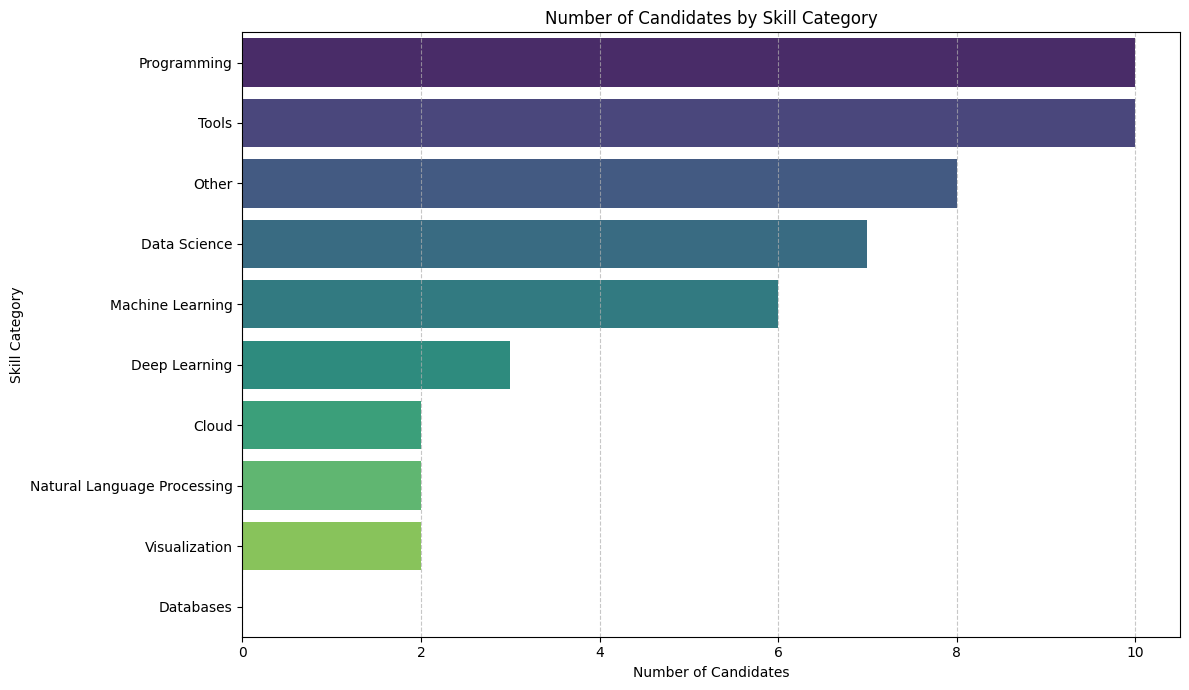

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a reverse map from standardized skill name to its category
skill_to_category_map = {}
for category, skills_map in skill_ontology.items():
    for standardized_skill_name in skills_map.keys():
        skill_to_category_map[standardized_skill_name] = category

# Initialize a dictionary to store candidate counts per category
category_counts = {category: 0 for category in skill_ontology.keys()}

# Iterate through each candidate to determine which categories they have skills in
for index, row in df_resumes.iterrows():
    candidate_extracted_skills = row['extracted_skills']

    # Track unique categories for the current candidate
    candidate_categories = set()
    for skill in candidate_extracted_skills:
        category = skill_to_category_map.get(skill) # Get the category for the skill
        if category:
            candidate_categories.add(category)

    # Increment counts for categories the candidate possesses
    for category in candidate_categories:
        category_counts[category] += 1

# Convert to DataFrame for easier plotting
df_category_counts = pd.DataFrame(category_counts.items(), columns=['Skill Category', 'Number of Candidates'])

print("**Number of Candidates Possessing Skills in Each Category:**")
display(df_category_counts.sort_values(by='Number of Candidates', ascending=False))

# Visualize the results
fig = plt.figure(figsize=(12, 7))
sns.barplot(x='Number of Candidates', y='Skill Category', data=df_category_counts.sort_values(by='Number of Candidates', ascending=False), palette='viridis')
plt.title('Number of Candidates by Skill Category')
plt.xlabel('Number of Candidates')
plt.ylabel('Skill Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()